In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

In [3]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")

#drop the duplicates
df = df.drop_duplicates()

#we now scale Amount and Time
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df['Amount'] = scaler.fit_transform(df[['Amount']])
df['Time'] = scaler.fit_transform(df[['Time']])

In [4]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Training class distribution:")
print(y_train_bal.value_counts())

Training class distribution:
Class
0    226602
1    226602
Name: count, dtype: int64


In [5]:
#now we will train each model
#Logistic Regression
print("Training: Logistic Regression")
lr = LogisticRegression(solver='liblinear', max_iter=100)
lr.fit(X_train_bal, y_train_bal)
print("Done.\n")

#Random Forest
print("Training: Random Forest")
rf = RandomForestClassifier(n_estimators=50, random_state=42, n_jobs=-1)
rf.fit(X_train_bal, y_train_bal)
print("Done.\n")

#Gradient Boosting
print("Training: Gradient Boosting")
gb = GradientBoostingClassifier()
gb.fit(X_train_bal, y_train_bal)
print("Done.\n")

#KNN
print("Training: KNN")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_bal, y_train_bal)
print("Done.\n")

#XGBoost
print("Training: XGBoost")
xgb = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
xgb.fit(X_train_bal, y_train_bal)
print("Done.\n")

#LightGBM
print("Training: LightGBM")
lgbm = LGBMClassifier(n_estimators=200, learning_rate=0.05, max_depth=-1, random_state=42)
lgbm.fit(X_train_bal, y_train_bal)
print("Done.\n")

#collect all models for reference
models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "Gradient Boosting": gb,
    "KNN": knn,
    "XGBoost": xgb,
    "LightGBM": lgbm
}

print("All models trained successfully.")

Training: Logistic Regression
Done.

Training: Random Forest
Done.

Training: Gradient Boosting
Done.

Training: KNN
Done.

Training: XGBoost
Done.

Training: LightGBM
[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.088219 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Done.

All models trained successfully.


In [6]:
#noww e will test threshold for every model
from sklearn.metrics import f1_score

thresholds = np.arange(0.1, 0.9, 0.05)

best_thresholds = {}  #for stores best threshold per model
best_f1_scores = {}   #this stores best f1 per model
all_probs = {}        #and this stores probabilities (which we be reused in later steps)

for name, model in models.items():
    
    probs = model.predict_proba(X_test)[:, 1]
    all_probs[name] = probs
    
    best_t = 0
    best_f1 = 0
    
    for t in thresholds:
        preds = (probs >= t).astype(int)
        score = f1_score(y_test, preds)
        
        if score > best_f1:
            best_f1 = score
            best_t = t
    
    best_thresholds[name] = best_t
    best_f1_scores[name] = best_f1
    
    print(f"{name} → Best Threshold: {best_t:.2f} | Best F1: {best_f1:.4f}")

Logistic Regression → Best Threshold: 0.85 | Best F1: 0.2812
Random Forest → Best Threshold: 0.40 | Best F1: 0.8427
Gradient Boosting → Best Threshold: 0.85 | Best F1: 0.5500
KNN → Best Threshold: 0.80 | Best F1: 0.6897
XGBoost → Best Threshold: 0.85 | Best F1: 0.7732
LightGBM → Best Threshold: 0.85 | Best F1: 0.8043


In [7]:
threshold_summary = pd.DataFrame({
    "Model": list(best_thresholds.keys()),
    "Best Threshold": list(best_thresholds.values()),
    "Best F1 Score": list(best_f1_scores.values())
})

print(threshold_summary.to_string(index=False))

              Model  Best Threshold  Best F1 Score
Logistic Regression            0.85       0.281250
      Random Forest            0.40       0.842697
  Gradient Boosting            0.85       0.550000
                KNN            0.80       0.689655
            XGBoost            0.85       0.773196
           LightGBM            0.85       0.804348


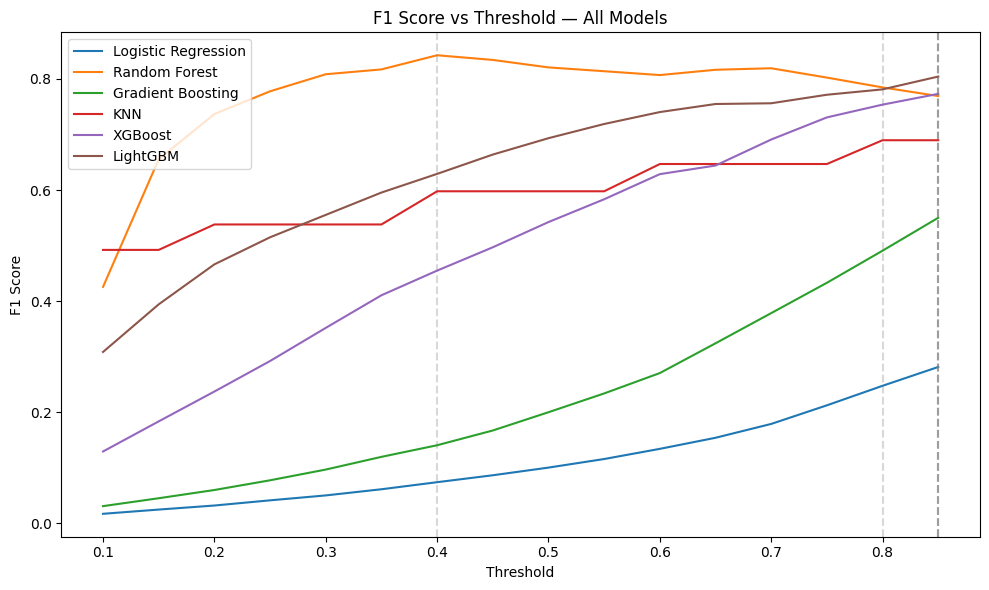

In [8]:
plt.figure(figsize=(10, 6))

for name, probs in all_probs.items():
    scores = [f1_score(y_test, (probs >= t).astype(int)) for t in thresholds]
    plt.plot(thresholds, scores, label=name)
    # Mark the best threshold for each model
    plt.axvline(x=best_thresholds[name], color='gray', linestyle='--', alpha=0.3)

plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold — All Models")
plt.legend()
plt.tight_layout()
plt.show()

In [9]:
from sklearn.ensemble import VotingClassifier

voting_model = VotingClassifier(
    estimators=[
        ('rf', rf),
        ('xgb', xgb),
        ('lgbm', lgbm)
    ],
    voting='soft'  # uses predicted probabilities, not just votes
)

voting_model.fit(X_train_bal, y_train_bal)
print("Voting Classifier trained successfully.")

[LightGBM] [Info] Number of positive: 226602, number of negative: 226602
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.084954 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 453204, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
Voting Classifier trained successfully.


In [10]:
voting_probs = voting_model.predict_proba(X_test)[:, 1]

In [11]:
#now we will find the best threshold for voting classifier
best_t_voting = 0
best_f1_voting = 0
voting_scores = []

for t in thresholds:
    preds = (voting_probs >= t).astype(int)
    score = f1_score(y_test, preds)
    voting_scores.append(score)
    
    if score > best_f1_voting:
        best_f1_voting = score
        best_t_voting = t

print(f"Voting Classifier → Best Threshold: {best_t_voting:.2f} | Best F1: {best_f1_voting:.4f}")

Voting Classifier → Best Threshold: 0.75 | Best F1: 0.8372


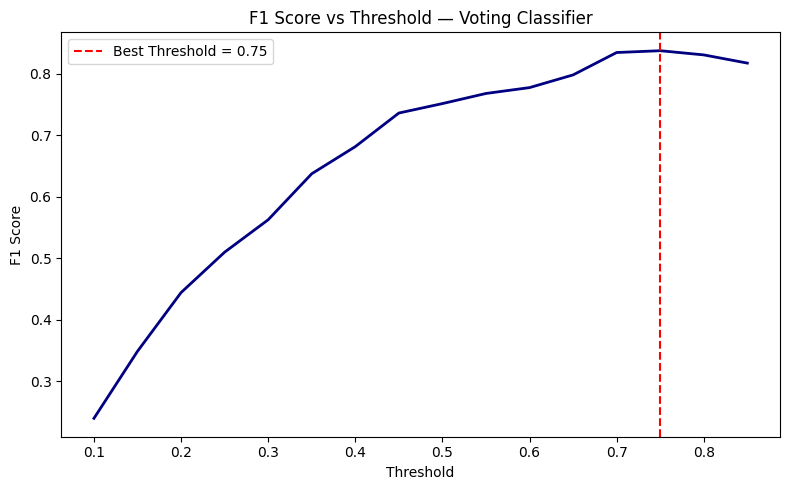

In [12]:
#wew ill plot f1 vs threshold for voting classifier
plt.figure(figsize=(8, 5))
plt.plot(thresholds, voting_scores, color='navy', linewidth=2)
plt.axvline(x=best_t_voting, color='red', linestyle='--', label=f"Best Threshold = {best_t_voting:.2f}")
plt.xlabel("Threshold")
plt.ylabel("F1 Score")
plt.title("F1 Score vs Threshold — Voting Classifier")
plt.legend()
plt.tight_layout()
plt.show()

              Model  ROC-AUC
  Voting Classifier   0.9824
            XGBoost   0.9793
  Gradient Boosting   0.9771
Logistic Regression   0.9620
           LightGBM   0.9559
      Random Forest   0.9520
                KNN   0.9100


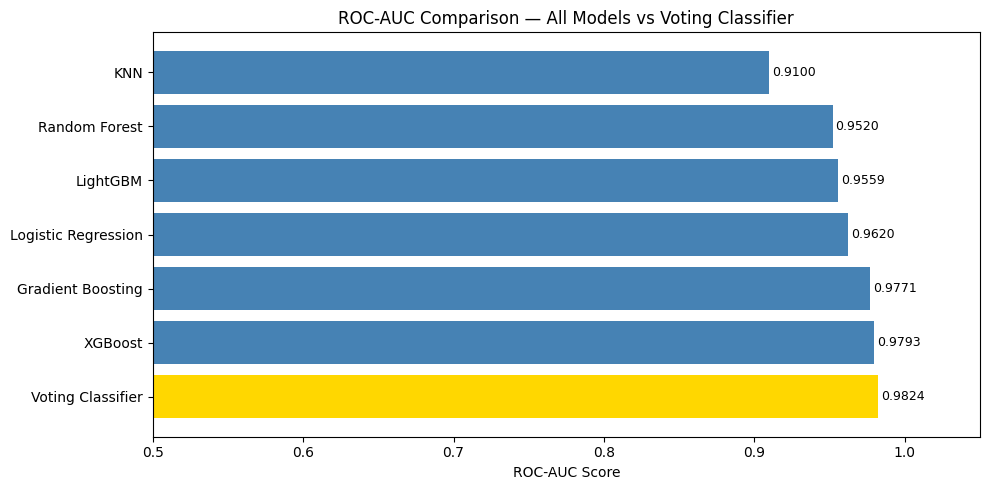

In [20]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Calculate AUC for each individual model
auc_results = []

for name, probs in all_probs.items():
    auc = roc_auc_score(y_test, probs)
    auc_results.append({"Model": name, "ROC-AUC": round(auc, 4)})

# Add voting classifier
voting_auc = roc_auc_score(y_test, voting_probs)
auc_results.append({"Model": "Voting Classifier", "ROC-AUC": round(voting_auc, 4)})

# Build and display table
auc_df = pd.DataFrame(auc_results).sort_values("ROC-AUC", ascending=False).reset_index(drop=True)
print(auc_df.to_string(index=False))

# Bar chart
plt.figure(figsize=(10, 5))
colors = ['gold' if m == 'Voting Classifier' else 'steelblue' for m in auc_df['Model']]
plt.barh(auc_df['Model'], auc_df['ROC-AUC'], color=colors)
plt.xlabel("ROC-AUC Score")
plt.title("ROC-AUC Comparison — All Models vs Voting Classifier")
plt.xlim(0.5, 1.05)

# Add value labels on bars
for i, val in enumerate(auc_df['ROC-AUC']):
    plt.text(val + 0.002, i, f"{val:.4f}", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [13]:
comparison_df = threshold_summary.copy()

voting_row = pd.DataFrame([{
    "Model": "Voting Classifier",
    "Best Threshold": best_t_voting,
    "Best F1 Score": best_f1_voting
}])

comparison_df = pd.concat([comparison_df, voting_row], ignore_index=True)

print(comparison_df.to_string(index=False))

              Model  Best Threshold  Best F1 Score
Logistic Regression            0.85       0.281250
      Random Forest            0.40       0.842697
  Gradient Boosting            0.85       0.550000
                KNN            0.80       0.689655
            XGBoost            0.85       0.773196
           LightGBM            0.85       0.804348
  Voting Classifier            0.75       0.837209


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, precision_recall_curve

final_preds = (voting_probs >= best_t_voting).astype(int)

print(f"Using Final Threshold: {best_t_voting:.2f}\n")

print("Classification Report:")
print(classification_report(y_test, final_preds))

print("Confusion Matrix:")
print(confusion_matrix(y_test, final_preds))

print("ROC-AUC Score:", roc_auc_score(y_test, voting_probs))

Using Final Threshold: 0.75

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56651
           1       0.94      0.76      0.84        95

    accuracy                           1.00     56746
   macro avg       0.97      0.88      0.92     56746
weighted avg       1.00      1.00      1.00     56746

Confusion Matrix:
[[56646     5]
 [   23    72]]
ROC-AUC Score: 0.9824454253141813


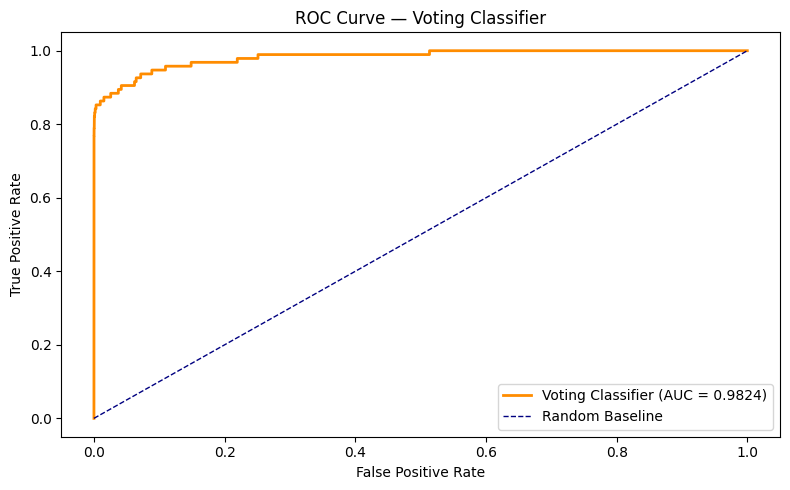

In [19]:
from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, voting_probs)
auc_score = roc_auc_score(y_test, voting_probs)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, color='darkorange', linewidth=2, label=f"Voting Classifier (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], color='navy', linewidth=1, linestyle='--', label="Random Baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Voting Classifier")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

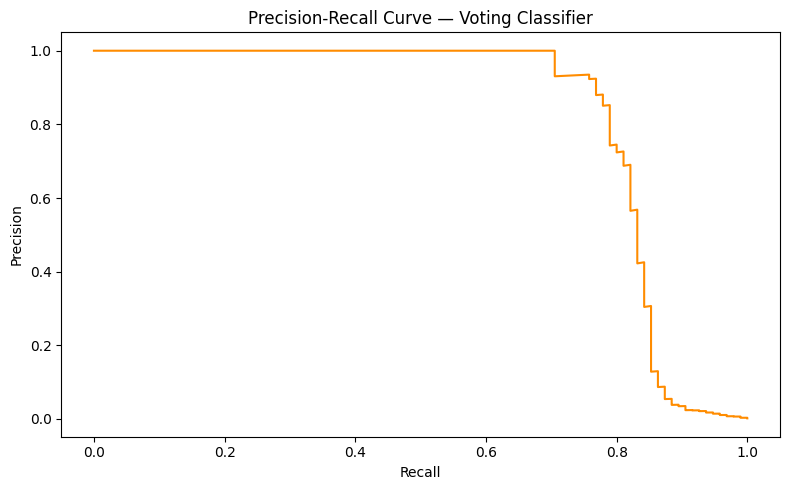

In [15]:
precision, recall, _ = precision_recall_curve(y_test, voting_probs)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, color='darkorange')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve — Voting Classifier")
plt.tight_layout()
plt.show()

In [16]:
def classify_transaction(prob, fraud_threshold):
    if prob >= fraud_threshold:
        return "Fraud"
    elif prob >= (fraud_threshold / 2):
        return "Suspicious"
    else:
        return "Normal"

three_class_preds = [classify_transaction(p, best_t_voting) for p in voting_probs]

Normal        56607
Fraud            77
Suspicious       62
Name: count, dtype: int64


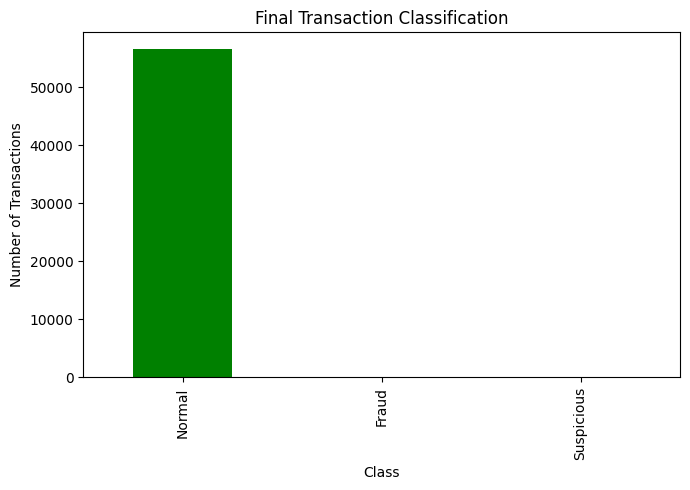

In [17]:
class_counts = pd.Series(three_class_preds).value_counts()

print(class_counts)

class_counts.plot(
    kind='bar',
    figsize=(7, 5),
    title="Final Transaction Classification",
    color=['green', 'orange', 'red']
)
plt.xlabel("Class")
plt.ylabel("Number of Transactions")
plt.tight_layout()
plt.show()

In [18]:
results_final = pd.DataFrame({
    "Probability": voting_probs,
    "Predicted Class": three_class_preds
})

print(results_final.head(10))

   Probability Predicted Class
0     0.000350          Normal
1     0.000426          Normal
2     0.004126          Normal
3     0.000515          Normal
4     0.009384          Normal
5     0.002213          Normal
6     0.000776          Normal
7     0.000040          Normal
8     0.002640          Normal
9     0.000503          Normal


In [24]:
# Simulate a real incoming transaction
# Column order must match training data
sample_transaction = X_test.iloc[0].to_dict()  # using a real test sample

def predict_transaction(transaction_dict, model, threshold):
    
    # Convert to DataFrame to match model input format
    df_input = pd.DataFrame([transaction_dict])
    
    # Get fraud probability
    prob = model.predict_proba(df_input)[:, 1][0]
    
    # Classify
    label = classify_transaction(prob, threshold)
    
    print("=" * 40)
    print("   TRANSACTION FRAUD DETECTION RESULT")
    print("=" * 40)
    print(f"  Fraud Probability : {prob:.4f} ({prob*100:.2f}%)")
    print(f"  Classification    : {label}")
    print("=" * 40)
    
    if label == "Fraud":
        print("  [BLOCK] ACTION: Block transaction immediately")
    elif label == "Suspicious":
        print("  [REVIEW] ACTION: Flag for manual review")
    else:
        print("  [APPROVE] ACTION: Approve transaction")
    print("=" * 40)
    
    return label

# Pick one example of each class for demonstration
fraud_idx = y_test[y_test == 1].index[0]
normal_idx = y_test[y_test == 0].index[0]

# Find a suspicious sample (probability between threshold/2 and threshold)
suspicious_idx = None
for idx in X_test.index:
    prob = voting_model.predict_proba(X_test.loc[[idx]])[:, 1][0]
    if (best_t_voting / 2) <= prob < best_t_voting:
        suspicious_idx = idx
        break

print("=== Demonstrating All 3 Classifications ===\n")

for label_name, idx in [("Normal", normal_idx), ("Suspicious", suspicious_idx), ("Fraud", fraud_idx)]:
    print(f"--- Sample: Expected {label_name} ---")
    sample = X_test.loc[idx].to_dict()
    predict_transaction(sample, voting_model, best_t_voting)
    print()

=== Demonstrating All 3 Classifications ===

--- Sample: Expected Normal ---
   TRANSACTION FRAUD DETECTION RESULT
  Fraud Probability : 0.0004 (0.04%)
  Classification    : Normal
  [APPROVE] ACTION: Approve transaction

--- Sample: Expected Suspicious ---
   TRANSACTION FRAUD DETECTION RESULT
  Fraud Probability : 0.4248 (42.48%)
  Classification    : Suspicious
  [REVIEW] ACTION: Flag for manual review

--- Sample: Expected Fraud ---
   TRANSACTION FRAUD DETECTION RESULT
  Fraud Probability : 0.9926 (99.26%)
  Classification    : Fraud
  [BLOCK] ACTION: Block transaction immediately



        COST-SENSITIVE ANALYSIS
  True Positives  (caught fraud)   : 72
  False Negatives (missed fraud)   : 23
  False Positives (false alarms)   : 5
  True Negatives  (correct normal) : 56646
---------------------------------------------
  Avg fraud loss per transaction   : $500
  Investigation cost per alarm     : $15
---------------------------------------------
  Cost of missed fraud (FN)        : $11,500
  Cost of false alarms (FP)        : $75
  Total model cost                 : $11,575
---------------------------------------------
  Cost without any model           : $47,500
  Savings from using this model    : $35,925
  Cost reduction                   : 75.6%


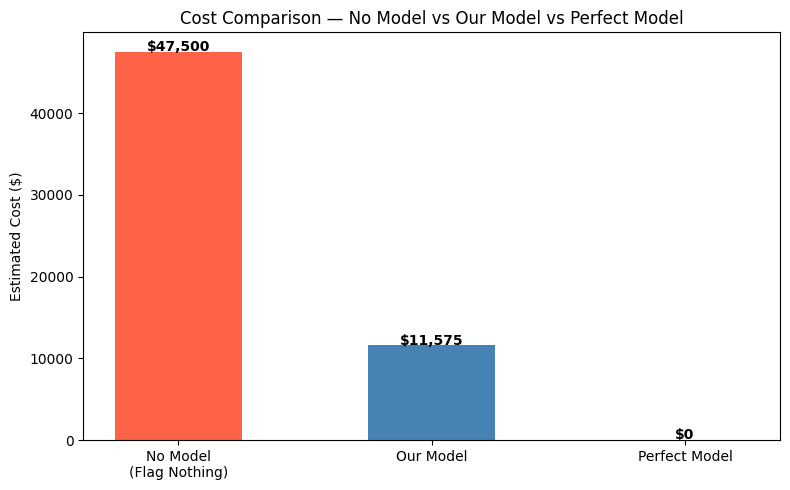

In [25]:
# Cost-Sensitive Analysis
# In real fraud detection, costs are asymmetric:
# Missing a fraud (False Negative) is far more
# expensive than a false alarm (False Positive)
# -----------------------------------------------

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, final_preds)
tn, fp, fn, tp = cm.ravel()

# Cost assumptions (industry-informed estimates)
AVG_FRAUD_AMOUNT    = 500   # average loss per missed fraud transaction ($)
INVESTIGATION_COST  = 15    # cost of manually investigating a false alarm ($)

# Calculate costs
cost_false_negatives = fn * AVG_FRAUD_AMOUNT
cost_false_positives = fp * INVESTIGATION_COST
total_cost           = cost_false_negatives + cost_false_positives

# What would it cost with NO model (flag nothing)?
cost_no_model = (tp + fn) * AVG_FRAUD_AMOUNT

# What would it cost with a PERFECT model?
cost_perfect_model = 0

# Savings
savings = cost_no_model - total_cost

print("=" * 45)
print("        COST-SENSITIVE ANALYSIS")
print("=" * 45)
print(f"  True Positives  (caught fraud)   : {tp}")
print(f"  False Negatives (missed fraud)   : {fn}")
print(f"  False Positives (false alarms)   : {fp}")
print(f"  True Negatives  (correct normal) : {tn}")
print("-" * 45)
print(f"  Avg fraud loss per transaction   : ${AVG_FRAUD_AMOUNT}")
print(f"  Investigation cost per alarm     : ${INVESTIGATION_COST}")
print("-" * 45)
print(f"  Cost of missed fraud (FN)        : ${cost_false_negatives:,}")
print(f"  Cost of false alarms (FP)        : ${cost_false_positives:,}")
print(f"  Total model cost                 : ${total_cost:,}")
print("-" * 45)
print(f"  Cost without any model           : ${cost_no_model:,}")
print(f"  Savings from using this model    : ${savings:,}")
print(f"  Cost reduction                   : {(savings/cost_no_model)*100:.1f}%")
print("=" * 45)

# Visualise
categories = ['No Model\n(Flag Nothing)', 'Our Model', 'Perfect Model']
costs = [cost_no_model, total_cost, cost_perfect_model]
bar_colors = ['tomato', 'steelblue', 'mediumseagreen']

plt.figure(figsize=(8, 5))
bars = plt.bar(categories, costs, color=bar_colors, width=0.5)

for bar, cost in zip(bars, costs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
             f"${cost:,}", ha='center', fontsize=10, fontweight='bold')

plt.ylabel("Estimated Cost ($)")
plt.title("Cost Comparison — No Model vs Our Model vs Perfect Model")
plt.tight_layout()
plt.show()

#  Fraud Detection Model Card

## Overview
This notebook presents a machine learning pipeline for real-time credit card fraud detection.
The model classifies each transaction into one of three categories: **Fraud**, **Suspicious**, or **Normal**.

---

## Dataset
- **Source:** Credit Card Fraud Detection — Kaggle (MLG-ULB, Université Libre de Bruxelles)
- **Size:** 284,807 transactions (after removing duplicates)
- **Class Imbalance:** ~0.17% fraud cases
- **Balancing Strategy:** SMOTE (Synthetic Minority Oversampling Technique)

---

## Pipeline Summary
| Step | Detail |
|------|--------|
| Preprocessing | StandardScaler on Amount and Time features |
| Balancing | SMOTE → 226,602 samples per class |
| Models Trained | Logistic Regression, Random Forest, Gradient Boosting, KNN, XGBoost, LightGBM |
| Final Ensemble | Soft Voting Classifier (Random Forest + XGBoost + LightGBM) |
| Threshold Tuning | Per-model F1 optimisation + voting classifier threshold search |

---

## Final Model Performance
| Metric | Value |
|--------|-------|
| ROC-AUC | 0.9824 |
| F1 Score (Fraud class) | 0.84 |
| Precision (Fraud class) | 0.94 |
| Recall (Fraud class) | 0.76 |
| False Positives | 5 |
| False Negatives | 23 |
| Best Threshold | 0.75 |

---

## Classification Logic
| Probability | Classification | Action |
|-------------|---------------|--------|
| ≥ 0.75 | 🔴 Fraud | Block transaction immediately |
| ≥ 0.375 | 🟡 Suspicious | Flag for manual review |
| < 0.375 | 🟢 Normal | Approve transaction |

---

## Model Selection Rationale
Random Forest, XGBoost, and LightGBM were selected for the final ensemble because:
- All three are tree-based models well suited for tabular data
- They offer fast inference suitable for real-time transaction processing
- Each uses a different learning strategy (bagging vs two different boosting approaches), providing genuine ensemble diversity
- Logistic Regression, Gradient Boosting, and KNN were dropped due to lower performance and/or production constraints

---

## Real-World Considerations
- **False Negatives are costly:** Each missed fraud transaction carries a financial and reputational cost far exceeding a false alarm
- **Threshold is tunable:** The 0.75 threshold can be adjusted based on business risk tolerance
- **Model is saved** via joblib for deployment in a production inference pipeline

In [27]:
import joblib

# Save the trained voting classifier
joblib.dump(voting_model, 'voting_fraud_model.pkl')

# Save the best threshold so inference uses the same value
joblib.dump(best_t_voting, 'best_threshold.pkl')

print("=" * 40)
print("       MODEL SAVED SUCCESSFULLY")
print("=" * 40)
print(f"  Model    : voting_fraud_model.pkl")
print(f"  Threshold: best_threshold.pkl")
print(f"  Threshold Value: {best_t_voting:.2f}")
print("=" * 40)

# Demonstrate loading and using the saved model
print("\n--- Verifying saved model loads correctly ---\n")

loaded_model     = joblib.load('voting_fraud_model.pkl')
loaded_threshold = joblib.load('best_threshold.pkl')

# Quick sanity check — run one prediction with loaded model
sample      = X_test.iloc[0].to_dict()
df_input    = pd.DataFrame([sample])
prob        = loaded_model.predict_proba(df_input)[:, 1][0]
label       = classify_transaction(prob, loaded_threshold)

print(f"  Test prediction with loaded model:")
print(f"  Fraud Probability : {prob:.4f}")
print(f"  Classification    : {label}")
print("\n  Loaded model works correctly. Ready for deployment.")

       MODEL SAVED SUCCESSFULLY
  Model    : voting_fraud_model.pkl
  Threshold: best_threshold.pkl
  Threshold Value: 0.75

--- Verifying saved model loads correctly ---

  Test prediction with loaded model:
  Fraud Probability : 0.0004
  Classification    : Normal

  Loaded model works correctly. Ready for deployment.
[LightGBM] [Info] Number of positive: 181281, number of negative: 181282
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.360002 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 362563, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499999 -> initscore=-0.000006
[LightGBM] [Info] Start training from score -0.000006
[LightGBM] [Info] Number of positive: 181281, number of negative: 181282
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.315970 seconds.
You 